# Lag 분석 — % Iron / % Silica Concentrate

**데이터**: preprocessed_1h.csv (IQR 클리핑 + Silica log 변환, 1시간 해상도)  
**목적**: 독립변수 X01~X21이 종속변수에 몇 시간 뒤에 영향을 미치는지 CCF로 규명

| 단계 | 내용 |
|------|------|
| Step 1 | 데이터 로드 및 확인 |
| Step 2 | CCF 계산 (0H ~ 12H) |
| Step 3 | CCF 히트맵 시각화 |
| Step 4 | Lag Sweep — R² 비교 |
| Step 5 | 최적 Lag 결론 |

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ── Step 1. 데이터 로드 ───────────────────────────────────────────────────────
df = pd.read_csv('preprocessed_1h.csv', index_col='date', parse_dates=True)

X_COLS = [
    '% Iron Feed', '% Silica Feed',
    'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
    'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
    'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
    'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
    'Flotation Column 07 Air Flow',
    'Flotation Column 01 Level', 'Flotation Column 02 Level',
    'Flotation Column 03 Level', 'Flotation Column 04 Level',
    'Flotation Column 05 Level', 'Flotation Column 06 Level',
    'Flotation Column 07 Level',
]
X_LABELS  = [f'X{str(i+1).zfill(2)}' for i in range(len(X_COLS))]
TARGETS   = ['% Iron Concentrate', '% Silica Concentrate']
TARGET_KOR= ['철 농축물 (Iron)', '실리카 농축물 (Silica)']

STEP_MAX = 12   # 12 스텝 = 12H (1시간 단위)

print(f'데이터 크기 : {df.shape[0]}행 × {df.shape[1]}열')
print(f'기간       : {df.index.min()} ~ {df.index.max()}')
print(f'결측 행    : {df.isna().any(axis=1).sum()}행 (공백 구간)')
print()
display(df[TARGETS].describe().round(3))

데이터 크기 : 4415행 × 23열
기간       : 2017-03-10 01:00:00 ~ 2017-09-09 23:00:00
결측 행    : 318행 (공백 구간)



,% Iron Concentrate,% Silica Concentrate
count,4097.000,4097.000
mean,65.050,1.150
std,1.118,0.314
min,62.135,0.470
25%,64.370,0.892
50%,65.210,1.099
75%,65.860,1.389
max,68.010,1.851


In [14]:
# ── Step 2. CCF 계산 (0H ~ 12H) ──────────────────────────────────────────────
# corr(X_t, Y_{t+lag})  lag>0: X가 Y에 선행

steps = list(range(0, STEP_MAX + 1))   # 0~12
ccf_dict = {}

for target in TARGETS:
    matrix = np.full((len(X_COLS), len(steps)), np.nan)
    for j, step in enumerate(steps):
        y_shifted = df[target].shift(-step)
        for i, col in enumerate(X_COLS):
            x    = df[col]
            mask = x.notna() & y_shifted.notna()
            if mask.sum() < 30:
                continue
            r, _ = pearsonr(x[mask], y_shifted[mask])
            matrix[i, j] = r
    ccf_dict[target] = pd.DataFrame(matrix, index=X_LABELS, columns=steps)

print('CCF 계산 완료')

# ── 변수별 최적 Lag 요약 ──────────────────────────────────────────────────────
for target, kor in zip(TARGETS, TARGET_KOR):
    ccf_df  = ccf_dict[target]
    summary = []
    for i, var in enumerate(X_LABELS):
        row    = ccf_df.loc[var].abs()
        best_s = row.idxmax()
        best_r = ccf_df.loc[var, best_s]
        summary.append({'Var': var, 'Name': X_COLS[i],
                        'Best Lag (H)': best_s, '|r|': round(abs(best_r), 4), 'r': round(best_r, 4)})
    summary_df = pd.DataFrame(summary).set_index('Var')

    print('=' * 65)
    print(f'  {kor} — 변수별 최적 Lag')
    print('=' * 65)
    display(summary_df)

    if target == '% Iron Concentrate':
        summary_iron   = summary_df
    else:
        summary_silica = summary_df

CCF 계산 완료
  철 농축물 (Iron) — 변수별 최적 Lag


,Name,Best Lag (H),|r|,r
Var,,,,
X01,% Iron Feed,9,0.0629,0.0629
X02,% Silica Feed,9,0.0521,-0.0521
X03,Starch Flow,0,0.0893,0.0893
X04,Amina Flow,0,0.1204,-0.1204
X05,Ore Pulp Flow,5,0.1188,0.1188
X06,Ore Pulp pH,3,0.2140,0.2140
X07,Ore Pulp Density,12,0.0336,-0.0336
X08,Flotation Column 01 Air Flow,4,0.1105,0.1105
X09,Flotation Column 02 Air Flow,3,0.0690,0.0690


  실리카 농축물 (Silica) — 변수별 최적 Lag


,Name,Best Lag (H),|r|,r
Var,,,,
X01,% Iron Feed,0,0.0745,-0.0745
X02,% Silica Feed,0,0.0676,0.0676
X03,Starch Flow,12,0.0900,-0.0900
X04,Amina Flow,0,0.1874,0.1874
X05,Ore Pulp Flow,11,0.0227,-0.0227
X06,Ore Pulp pH,3,0.1697,-0.1697
X07,Ore Pulp Density,2,0.0699,0.0699
X08,Flotation Column 01 Air Flow,4,0.2299,-0.2299
X09,Flotation Column 02 Air Flow,4,0.1821,-0.1821


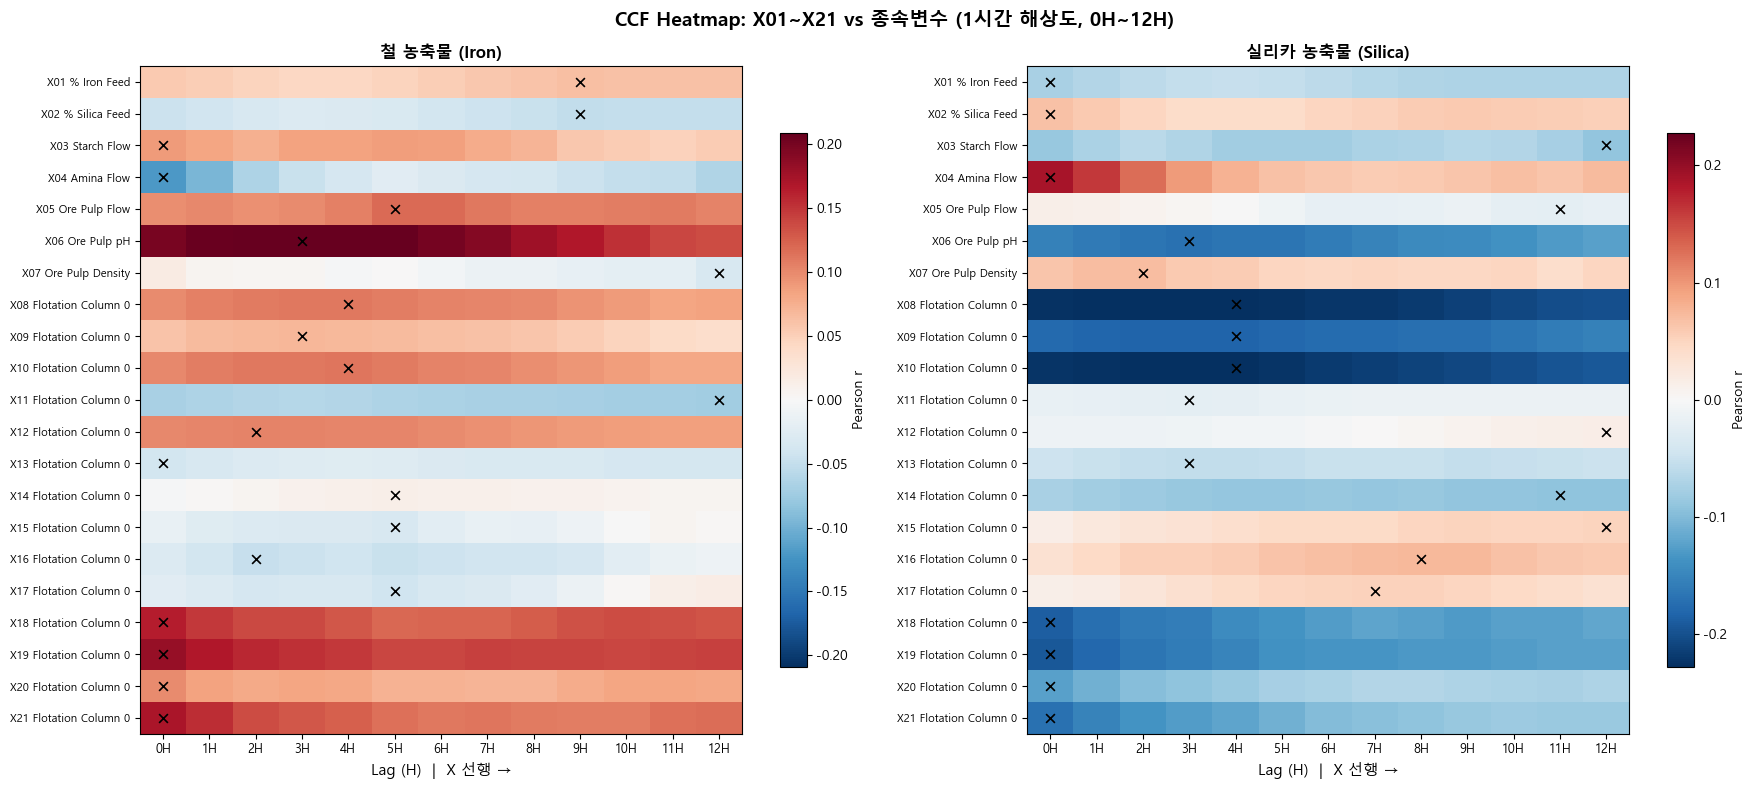

저장 완료: ccf_targets_1h.png


In [15]:
# ── Step 3. CCF 히트맵 시각화 ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('CCF Heatmap: X01~X21 vs 종속변수 (1시간 해상도, 0H~12H)', fontsize=14, fontweight='bold')

for ax, target, kor, summary_df in zip(
    axes, TARGETS, TARGET_KOR, [summary_iron, summary_silica]
):
    ccf_df = ccf_dict[target]
    matrix = ccf_df.values
    vmax   = np.nanpercentile(np.abs(matrix), 99)

    im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.set_xticks(range(len(steps)))
    ax.set_xticklabels([f'{h}H' for h in steps], fontsize=9)
    ax.set_yticks(range(len(X_LABELS)))
    ax.set_yticklabels(
        [f'{lb} {X_COLS[i][:18]}' for i, lb in enumerate(X_LABELS)], fontsize=8
    )
    ax.set_xlabel('Lag (H)  |  X 선행 →', fontsize=11)
    ax.set_title(kor, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)

    for i, var in enumerate(X_LABELS):
        best_s = summary_df.loc[var, 'Best Lag (H)']
        ax.scatter(best_s, i, marker='x', color='black', s=40, linewidths=1.2)

plt.tight_layout()
plt.savefig('ccf_targets_1h.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: ccf_targets_1h.png')

In [16]:
# ── Step 4. Lag Sweep — Linear Regression R² ─────────────────────────────────

def insample_r2(df, x_cols, target, lag):
    X_df = pd.DataFrame({col: df[col].shift(-lag) for col in x_cols}, index=df.index)
    y    = df[target]
    mask = X_df.notna().all(axis=1) & y.notna()
    if mask.sum() < 10:
        return np.nan
    X_arr, y_arr = X_df[mask].values, y[mask].values
    model = LinearRegression().fit(X_arr, y_arr)
    return r2_score(y_arr, model.predict(X_arr))

results = {}

for target, kor in zip(TARGETS, TARGET_KOR):
    r2_list = [insample_r2(df, X_COLS, target, s) for s in steps]
    results[target] = r2_list
    best_s = steps[np.argmax(r2_list)]
    print(f'{kor}')
    print(f'  Lag  | R²')
    print(f'  -----+--------')
    for s, r2 in zip(steps, r2_list):
        marker = '  ← 최대' if s == best_s else ''
        print(f'  {s:3d}H  | {r2:.4f}{marker}')
    print()

철 농축물 (Iron)
  Lag  | R²
  -----+--------
    0H  | 0.1624
    1H  | 0.1781
    2H  | 0.2085
    3H  | 0.2378  ← 최대
    4H  | 0.2352
    5H  | 0.2219
    6H  | 0.2006
    7H  | 0.1758
    8H  | 0.1587
    9H  | 0.1459
   10H  | 0.1427
   11H  | 0.1369
   12H  | 0.1344

실리카 농축물 (Silica)
  Lag  | R²
  -----+--------
    0H  | 0.1810
    1H  | 0.2069
    2H  | 0.2514
    3H  | 0.2987  ← 최대
    4H  | 0.2924
    5H  | 0.2702
    6H  | 0.2424
    7H  | 0.2163
    8H  | 0.1971
    9H  | 0.1829
   10H  | 0.1756
   11H  | 0.1651
   12H  | 0.1626



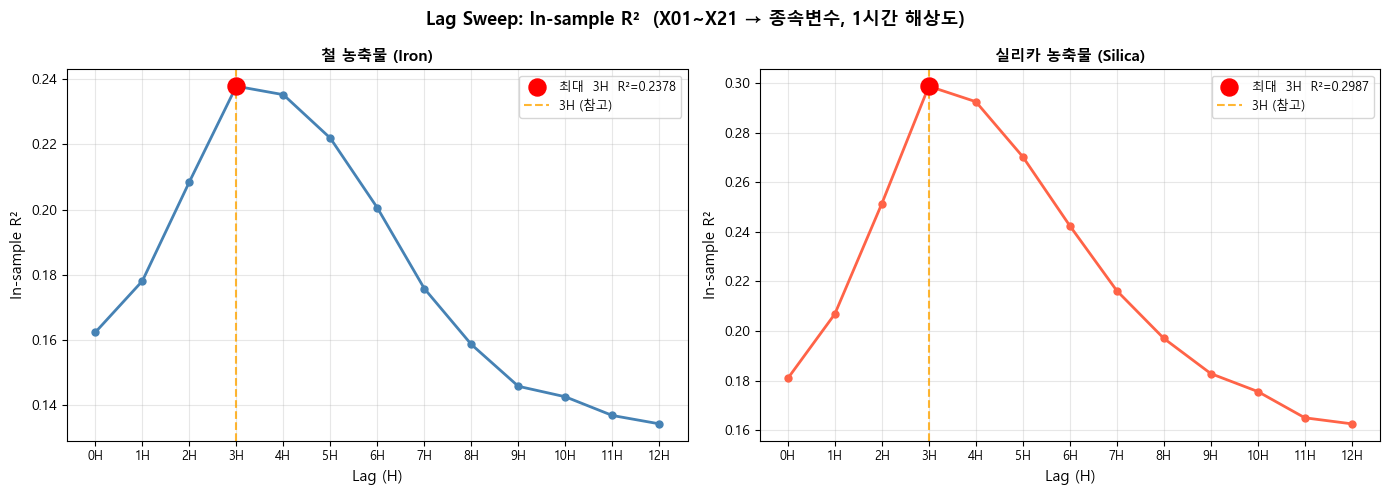

저장 완료: lag_sweep_targets_1h.png


In [17]:
# ── Step 5. Lag Sweep 시각화 ──────────────────────────────────────────────────

colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lag Sweep: In-sample R²  (X01~X21 → 종속변수, 1시간 해상도)', fontsize=13, fontweight='bold')

for ax, target, kor, color in zip(axes, TARGETS, TARGET_KOR, colors):
    r2_list = results[target]
    best_s  = steps[np.argmax(r2_list)]

    ax.plot(steps, r2_list, color=color, lw=2, marker='o', markersize=5)
    ax.scatter([best_s], [max(r2_list)], s=150, color='red', zorder=5,
               label=f'최대  {best_s}H  R²={max(r2_list):.4f}')
    ax.axvline(x=3, color='orange', lw=1.5, ls='--', alpha=0.8, label='3H (참고)')
    ax.set_xlabel('Lag (H)', fontsize=11)
    ax.set_ylabel('In-sample R²', fontsize=11)
    ax.set_title(kor, fontsize=11, fontweight='bold')
    ax.set_xticks(steps)
    ax.set_xticklabels([f'{h}H' for h in steps], fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lag_sweep_targets_1h.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: lag_sweep_targets_1h.png')

In [18]:
# ── Step 6. 결론 요약 ─────────────────────────────────────────────────────────

print('=' * 55)
print('  Lag 분석 결론 요약 (1시간 해상도)')
print('=' * 55)

for target, kor, summary_df in zip(TARGETS, TARGET_KOR, [summary_iron, summary_silica]):
    r2_list  = results[target]
    best_s   = steps[np.argmax(r2_list)]
    best_r2  = max(r2_list)
    r2_0h    = r2_list[0]
    top3     = summary_df.nlargest(3, '|r|')[['Name', 'Best Lag (H)', 'r']]

    print(f'\n[{kor}]')
    print(f'  R² (Lag 0H) : {r2_0h:.4f}')
    print(f'  R² 최대     : {best_r2:.4f}  @ Lag {best_s}H')
    print(f'  R² 개선     : +{best_r2 - r2_0h:.4f}')
    print(f'  상관 상위 3개 변수:')
    display(top3)

print('=' * 55)

  Lag 분석 결론 요약 (1시간 해상도)

[철 농축물 (Iron)]
  R² (Lag 0H) : 0.1624
  R² 최대     : 0.2378  @ Lag 3H
  R² 개선     : +0.0754
  상관 상위 3개 변수:


,Name,Best Lag (H),r
Var,,,
X06,Ore Pulp pH,3,0.2140
X19,Flotation Column 05 Level,0,0.1814
X21,Flotation Column 07 Level,0,0.1715



[실리카 농축물 (Silica)]
  R² (Lag 0H) : 0.1810
  R² 최대     : 0.2987  @ Lag 3H
  R² 개선     : +0.1177
  상관 상위 3개 변수:


,Name,Best Lag (H),r
Var,,,
X08,Flotation Column 01 Air Flow,4,-0.2299
X10,Flotation Column 03 Air Flow,4,-0.2272
X19,Flotation Column 05 Level,0,-0.1939
